In [1]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [11]:
file = '/eos/user/b/bbapi/MC_contacts/2024_signal_samples_WH/CMSSW_15_0_15/src/WH_2024_M15.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [3]:
events.fields

['event',
 'LHEReweightingWeight',
 'GenVtx',
 'TrackGenJetAK4',
 'Tau',
 'PFCand',
 'genTtbarId',
 'GenMET',
 'IsoTrack',
 'SubGenJetAK8',
 'LHEPart',
 'SoftActivityJetNjets5',
 'BeamSpot',
 'RawPFMET',
 'GenIsolatedPhoton',
 'FsrPhoton',
 'PSWeight',
 'PFMET',
 'HLTriggerFinalPath',
 'SoftActivityJetHT2',
 'CorrT1METJet',
 'SubJet',
 'HLT',
 'LHEPdfWeight',
 'Generator',
 'boostedTau',
 'CaloMET',
 'HLTriggerFirstPath',
 'Electron',
 'orbitNumber',
 'SoftActivityJet',
 'Flag',
 'Pileup',
 'Photon',
 'FatJet',
 'PuppiMET',
 'DeepMETResolutionTune',
 'TrigObj',
 'GenProton',
 'luminosityBlock',
 'L1Reco',
 'TauSpinner',
 'LHE',
 'SV',
 'bunchCrossing',
 'GenVisTau',
 'GenJetAK8',
 'DST',
 'Jet',
 'PVBS',
 'LHEWeight',
 'TrkMET',
 'run',
 'HTXS',
 'L1simulation',
 'GenPart',
 'FiducialMET',
 'Dataset',
 'TauProd',
 'L1',
 'GenJet',
 'SoftActivityJetNjets10',
 'LHEScaleWeight',
 'DeepMETResponseTune',
 'GenDressedLepton',
 'Rho',
 'PV',
 'OtherPV',
 'SoftActivityJetHT5',
 'RawPuppiMET',


In [4]:
events.Jet.fields

['chMultiplicity',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'UParTAK4RegPtRawCorr',
 'UParTAK4RegPtRawCorrNeutrino',
 'UParTAK4RegPtRawRes',
 'UParTAK4V1RegPtRawCorr',
 'UParTAK4V1RegPtRawCorrNeutrino',
 'UParTAK4V1RegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetCvNotB',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagUParTAK4B',
 'btagUParTAK4CvB',
 'btagUParTAK4CvL',
 'btagUParTAK4CvNotB',
 'btagUParTAK4Ele',
 'btagUParTAK4Mu',
 'btagUParTAK4QvG',
 'btagUParTAK4SvCB',
 'btagUParTAK4SvUDG',
 'btagUParTAK4TauVJet',
 'btagUParTAK4UDG',
 'btagUParTAK4probb',
 'btagUParTAK4probbb',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsi

In [6]:
events.Jet.pt*1

<Array [[55.1, 36.2, 21.3, 19.9], ..., [...]] type='280000 * var * float32[...'>

In [3]:
def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)


def photon_preselections(
    photons: ak.Array,
    events: ak.Array,
    electron_veto=True,
    revert_electron_veto=False,
    year="2018",
    wp_medium=0.2783,
    IsFlag=False):
    """
    Apply full preselection on leptons, jets, and photons.
    Finally return only photons from events that pass all criteria.
    """

    print("Number of events before preselection:", len(events))

    # ------------------------
    # Lepton selection
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 30, 24

    else:
        raise ValueError(f"Unknown year {year}")

    electrons = events.Electron

    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &  # keep within tracker acceptance
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &  # remove transition
        (electrons.mvaIso_WP80) &        # tight MVA ID
        (electrons.pfRelIso03_all < 0.15)  # isolation cut
    )

    good_muons = (
        (events.Muon.pt > mu_pt_cut)
        & (np.abs(events.Muon.eta) < 2.4)
        & (events.Muon.pfRelIso03_all < 0.15)
    )

    one_ele = ak.num(events.Electron[good_electrons]) == 1
    one_mu = ak.num(events.Muon[good_muons]) == 1
    lepton_channel_mask = one_ele | one_mu
    # lepton_channel_mask = one_mu

    selected_electrons = events.Electron[good_electrons]
    print("selected_electrons", len(selected_electrons[ak.num(selected_electrons.pt)>0]))
    selected_muons = events.Muon[good_muons]
    print("selected_muons", len(selected_muons[ak.num(selected_muons.pt)>0]))
    selected_leptons = ak.concatenate([selected_electrons, selected_muons], axis=1)
    print("selected_leptons", len(selected_leptons[ak.num(selected_leptons.pt)>0]))
    print("selected Electrons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==11])>0]))
    print("selected Muons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==13])>0]))

    # ------------------------
    # Jet selection
    # ------------------------
    good_jets = (
        (events.Jet.pt > 20)
        & (np.abs(events.Jet.eta) < 2.4)
        # & (events.Jet.btagUParTAK4B > 0.1272)
    )
    selected_bjets = events.Jet[good_jets] 
    print("selected_b_jets: ", selected_bjets)
    at_least_two_bjets = ak.num(selected_bjets) >= 1

    # keep top 2 by DeepJet score
    # top2_bjets = selected_jets[ak.argsort(selected_jets.btagDeepFlavB, ascending=False)][:, :2]

    # ------------------------
    # Photon selection (from photon_preselection output)
    # ------------------------

    abs_eta = np.abs(photons.eta)

    # Barrel–endcap transition exclusion (1.442 ≤ |η| ≤ 1.566)
    valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

    # Barrel vs Endcap ID cuts
    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    # Apply region-specific MVA thresholds
    barrel_cut = is_barrel & (photons.mvaID > -0.02)
    endcap_cut = is_endcap & (photons.mvaID > -0.26)

    # Combine everything
    good_photons = (
        (photons.pt > 10)
        & valid_eta
        & (barrel_cut | endcap_cut)
        & (~photons.pixelSeed)
    )
    selected_photons = photons[good_photons]
    at_least_two_photons = ak.num(selected_photons) >= 2

    dr = delta_r_manual(selected_leptons, selected_photons)
    dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

    # ΔR between electrons and photons
    dr_electrons = delta_r_manual(selected_electrons, selected_photons)

    # ΔR between muons and photons
    dr_muons = delta_r_manual(selected_muons, selected_photons)


    event_mask = lepton_channel_mask & at_least_two_bjets & at_least_two_photons & dr_mask

    # ------------------------
    # Apply mask — keep length same, empties for failed events
    # ------------------------
    empty_photons = ak.Array([[]] * len(events))
    empty_bjets = ak.Array([[]] * len(events))
    empty_leptons = ak.Array([[]] * len(events))

    filtered_photons = ak.where(event_mask, selected_photons, empty_photons)
    filtered_jets = ak.where(event_mask, selected_bjets, empty_bjets)
    filtered_leptons = ak.where(event_mask, selected_leptons, empty_leptons)

    return filtered_photons, filtered_jets, filtered_leptons

In [12]:
fp, fj, fl = photon_preselections(
    events.Photon,
    events,
    electron_veto=True,
    revert_electron_veto=False,
    year="2024",
    wp_medium=0.2783,
    IsFlag=False)

Number of events before preselection: 280000
selected_electrons 46449
selected_muons 68119
selected_leptons 113187
selected Electrons 46449
selected Muons 68119
selected_b_jets:  [[{chMultiplicity: ??, nConstituents: ??, nElectrons: ??, ...}], ..., [...]]


In [12]:
len(fj)

280000

In [63]:
fj = fj[ak.num(fj.pt)>0]

In [55]:
fj.pt

<Array [[71.5, 44.8, 34], ..., [44.5, ...]] type='21666 * var * float32[par...'>

In [20]:
fj.btagUParTAK4B*1

<Array [[0.996, 0.114, ..., 0.0417], ...] type='27251 * var * float32[param...'>

In [6]:
thr  = 0.1272      # example
thr2 = 0.38      # example

In [7]:
passB = fj.btagUParTAK4B > thr
n_passB = ak.sum(passB, axis=1)
evt_mask = n_passB == 1
btag_probbb_sel = fj.btagUParTAK4probbb[evt_mask][passB[evt_mask]]
btag_4B_sel = fj.btagUParTAK4B[evt_mask][passB[evt_mask]]
# print(ak.all(ak.num(btag_probbb_sel)))
probbb_values = ak.to_numpy(ak.flatten(btag_probbb_sel))
AK4B_values = ak.to_numpy(ak.flatten(btag_4B_sel))
# print("probbb_values",probbb_values)
print("Number of selected events with exactly one b-tagged jet:", len(probbb_values))
fraction = np.mean(probbb_values > thr2)
print("Total number of events passing dijet b-tag selection in exactly one b-tagged jet events: ", np.sum(probbb_values > thr2))
print(f"Fraction passing probbb > {thr2}: {fraction:.3f}")

Number of selected events with exactly one b-tagged jet: 14758
Total number of events passing dijet b-tag selection in exactly one b-tagged jet events:  44
Fraction passing probbb > 0.38: 0.003


In [10]:
passB = fj.btagUParTAK4B > thr
n_passB = ak.sum(passB, axis=1)
evt_mask = n_passB == 1
btag_probbb_sel = fj.btagUParTAK4probbb[evt_mask][passB[evt_mask]]
btag_4B_sel = fj.btagUParTAK4B[evt_mask][passB[evt_mask]]
# print(ak.all(ak.num(btag_probbb_sel)))
probbb_values = ak.to_numpy(ak.flatten(btag_probbb_sel))
AK4B_values = ak.to_numpy(ak.flatten(btag_4B_sel))
# print("probbb_values",probbb_values)
print("Number of selected events with exactly one b-tagged jet:", len(probbb_values))
fraction = np.mean(probbb_values > thr2)
print("Total number of events passing dijet b-tag selection in exactly one b-tagged jet events: ", np.sum(probbb_values > thr2))
print(f"Fraction passing probbb > {thr2}: {fraction:.3f}")

Number of selected events with exactly one b-tagged jet: 14289
Total number of events passing dijet b-tag selection in exactly one b-tagged jet events:  1100
Fraction passing probbb > 0.38: 0.077


In [13]:
passB = fj.btagUParTAK4B > thr
n_passB = ak.sum(passB, axis=1)
evt_mask = n_passB == 1
btag_probbb_sel = fj.btagUParTAK4probbb[evt_mask][passB[evt_mask]]
btag_4B_sel = fj.btagUParTAK4B[evt_mask][passB[evt_mask]]
# print(ak.all(ak.num(btag_probbb_sel)))
probbb_values = ak.to_numpy(ak.flatten(btag_probbb_sel))
AK4B_values = ak.to_numpy(ak.flatten(btag_4B_sel))
# print("probbb_values",probbb_values)
print("Number of selected events with exactly one b-tagged jet:", len(probbb_values))
fraction = np.mean(probbb_values > thr2)
print("Total number of events passing dijet b-tag selection in exactly one b-tagged jet events: ", np.sum(probbb_values > thr2))
print(f"Fraction passing probbb > {thr2}: {fraction:.3f}")

Number of selected events with exactly one b-tagged jet: 14604
Total number of events passing dijet b-tag selection in exactly one b-tagged jet events:  6319
Fraction passing probbb > 0.38: 0.433


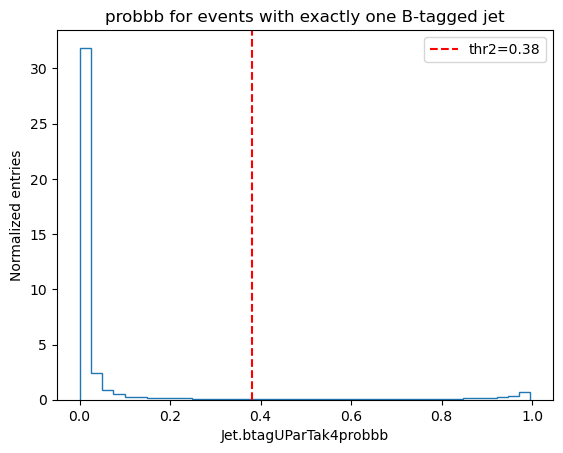

In [28]:
import matplotlib.pyplot as plt

plt.hist(probbb_values, bins=40, density=True, histtype="step")
plt.axvline(thr2, color="red", linestyle="--", label=f"thr2={thr2}")
plt.xlabel("Jet.btagUParTak4probbb")
plt.ylabel("Normalized entries")
plt.legend()
plt.title("probbb for events with exactly one B-tagged jet")
plt.show()

In [65]:
nbins = 40
xmin, xmax = 0.0, 1.0

h_probbb = ROOT.TH1F(
    "h_probbb",
    ";Jet btag score;Normalized entries",
    nbins, xmin, xmax
)

h_btagB = ROOT.TH1F(
    "h_btagB",
    ";Jet btag score;Normalized entries",
    nbins, xmin, xmax
)

for v in probbb_values:
    h_probbb.Fill(v)

for v in AK4B_values:
    h_btagB.Fill(v)

if h_probbb.Integral() > 0:
    h_probbb.SetMinimum(0.05)
    h_probbb.Scale(1.0 / h_probbb.Integral())

if h_btagB.Integral() > 0:
    h_btagB.SetMinimum(0.05)
    h_btagB.Scale(1.0 / h_btagB.Integral())


h_probbb.SetLineColor(ROOT.kBlue+1)
h_probbb.SetLineWidth(2)

h_btagB.SetLineColor(ROOT.kRed+1)
h_btagB.SetLineWidth(2)
h_btagB.SetLineStyle(2)

line = ROOT.TLine(thr2, 0, thr2, max(h_probbb.GetMaximum(), h_btagB.GetMaximum()))
line.SetLineStyle(7)
line.SetLineColor(ROOT.kBlack)
line.SetLineWidth(2)

c = ROOT.TCanvas("c", "btag overlay", 800, 600)
c.SetLogy()

h_probbb.Draw("hist")
h_btagB.Draw("hist same")
line.Draw()

leg = ROOT.TLegend(0.50, 0.65, 0.78, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.04)

leg.AddEntry(h_probbb, "TAK4 proBBB", "l")
leg.AddEntry(h_btagB,  "TAK4 B",      "l")
leg.AddEntry(line,     f"thr2 = {thr2}", "l")

leg.Draw()

title = ROOT.TLatex()
title.SetNDC()
title.SetTextSize(0.04)
title.DrawLatex(0.12, 0.92,
    "Exactly 1 jet with btagUParTak4B > thr"
)

c.Update()
c.SaveAs("btagUParTAK4B_vs_probbb_M60.png")
c.SaveAs("btagUParTAK4B_vs_probbb_M60.pdf")


Warning in <TROOT::Append>: Replacing existing TH1: h_probbb (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_btagB (Potential memory leak).
Info in <TCanvas::Print>: png file btagUParTAK4B_vs_probbb_M60.png has been created
Info in <TCanvas::Print>: pdf file btagUParTAK4B_vs_probbb_M60.pdf has been created


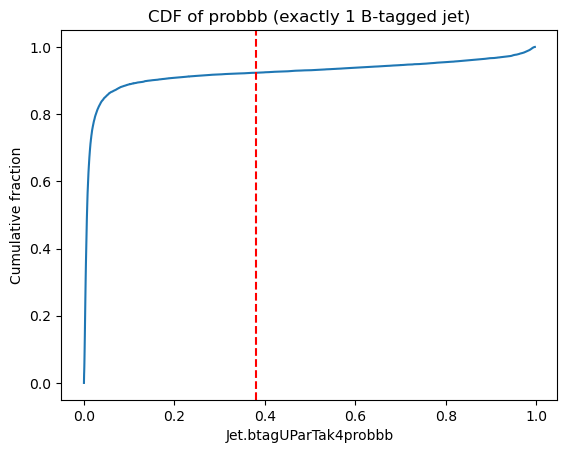

In [29]:
vals = np.sort(probbb_values)
cdf  = np.arange(1, len(vals)+1) / len(vals)

plt.plot(vals, cdf)
plt.axvline(thr2, color="red", linestyle="--")
plt.xlabel("Jet.btagUParTak4probbb")
plt.ylabel("Cumulative fraction")
plt.title("CDF of probbb (exactly 1 B-tagged jet)")
plt.show()


In [66]:
ROOT.gStyle.SetOptStat(0)

# inputs
# probbb_values : 1D numpy array
# thr2          : threshold value

# --- histogram ---
nbins = 100
xmin, xmax = 0.0, 1.0

h = ROOT.TH1F(
    "h_probbb",
    ";Jet.btagUParTak4probbb;Cumulative fraction",
    nbins, xmin, xmax
)

for v in probbb_values:
    h.Fill(v)

# normalize
if h.Integral() > 0:
    h.Scale(1.0 / h.Integral())

# cumulative distribution
h_cdf = h.GetCumulative()
h_cdf.SetLineColor(ROOT.kBlue+1)
h_cdf.SetLineWidth(2)
h_cdf.SetMinimum(0.0)
h_cdf.SetMaximum(1.05)

# CDF value at thr2
bin_thr = h_cdf.FindBin(thr2)
cdf_at_thr = h_cdf.GetBinContent(bin_thr)
eff_gt = 1.0 - cdf_at_thr

# threshold line
line = ROOT.TLine(thr2, 0.0, thr2, 1.0)
line.SetLineColor(ROOT.kRed+1)
line.SetLineStyle(7)
line.SetLineWidth(2)

# canvas
c = ROOT.TCanvas("c_cdf", "CDF", 800, 600)
h_cdf.Draw("hist")
line.Draw("same")

# text on plot
lat = ROOT.TLatex()
lat.SetNDC()
lat.SetTextSize(0.035)

lat.DrawLatex(0.55, 0.45, f"thr = {thr2:.3f}")
lat.DrawLatex(0.55, 0.40, f"CDF = {cdf_at_thr:.3f}")
lat.DrawLatex(0.55, 0.35, f"Eff(>thr) = {eff_gt:.3f}")

# title
lat.SetTextSize(0.04)
lat.DrawLatex(0.12, 0.92,
    "CDF of btagUParTak4probbb (exactly 1 B-tagged jet)"
)

c.Update()

c.SaveAs("btagUParTAK4probbb_CDF_M60.png")


Warning in <TROOT::Append>: Replacing existing TH1: h_probbb (Potential memory leak).
Info in <TCanvas::Print>: png file btagUParTAK4probbb_CDF_M60.png has been created


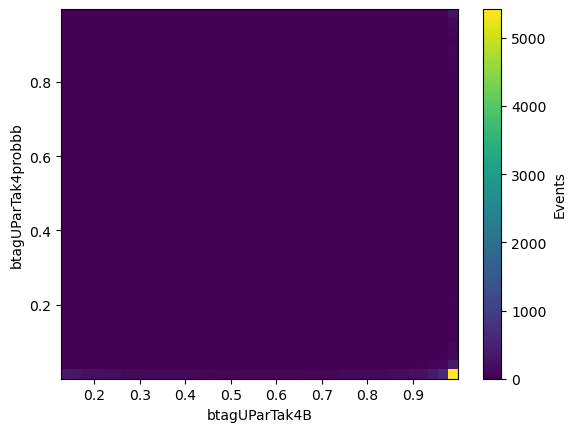

In [31]:
btagB_sel = fj.btagUParTAK4B[evt_mask][passB[evt_mask]]
btagB_vals = ak.to_numpy(ak.flatten(btagB_sel))

plt.hist2d(btagB_vals, probbb_values, bins=40)
plt.xlabel("btagUParTak4B")
plt.ylabel("btagUParTak4probbb")
plt.colorbar(label="Events")
plt.show()


In [67]:
ROOT.gStyle.SetPalette(ROOT.kViridis)

# inputs
# btagB_vals    : 1D numpy array
# probbb_values : 1D numpy array
# thr           : threshold on btagUParTak4B
# thr2          : threshold on btagUParTak4probbb

# --- ranges (tune if needed) ---
xbins, xmin, xmax = 40, 0.0, 1.0
ybins, ymin, ymax = 40, 0.0, 1.0

# --- 2D histogram ---
h2 = ROOT.TH2F(
    "h2_btag_corr",
    ";btagUParTak4B;btagUParTak4probbb",
    xbins, xmin, xmax,
    ybins, ymin, ymax
)

for x, y in zip(btagB_vals, probbb_values):
    h2.Fill(x, y)

# --- canvas ---
c = ROOT.TCanvas("c_corr", "btag correlation", 800, 700)
h2.Draw("COLZ")

# optional log z
# c.SetLogz()

# --- threshold lines ---
vline = ROOT.TLine(thr, ymin, thr, ymax)
vline.SetLineColor(ROOT.kRed+1)
vline.SetLineStyle(7)
vline.SetLineWidth(2)

hline = ROOT.TLine(xmin, thr2, xmax, thr2)
hline.SetLineColor(ROOT.kBlue+1)
hline.SetLineStyle(7)
hline.SetLineWidth(2)

vline.Draw("same")
hline.Draw("same")

# --- legend ---
leg = ROOT.TLegend(0.15, 0.80, 0.45, 0.90)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(vline,  f"TAK4B > {thr}",   "l")
leg.AddEntry(hline, f"probbb > {thr2}", "l")
leg.Draw()

# --- title ---
lat = ROOT.TLatex()
lat.SetNDC()
lat.SetTextSize(0.04)
lat.DrawLatex(
    0.12, 0.92,
    "btagUParTak4B vs btagUParTak4probbb (exactly 1 B-tagged jet)"
)

c.Update()

c.SaveAs("btagUParTAK4B_vs_probbb_2D_M60.png")


Warning in <TROOT::Append>: Replacing existing TH1: h2_btag_corr (Potential memory leak).
Info in <TCanvas::Print>: png file btagUParTAK4B_vs_probbb_2D_M60.png has been created
